# Библиотеки

In [2]:
import pandas as pd
from scipy import stats
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

# Подключение и загрузка данных

In [5]:
load_dotenv()  # Загружает переменные из .env в окружение
db_url = os.getenv('DB_URL')
engine = create_engine(db_url)

# Гипотеза 1: водители с рейтингом >4.8 зарабатывают больше

Средняя выручка (рейтинг >4.8): 72948
Средняя выручка (рейтинг ≤4.8): 73793
p-value: 0.1743
Вывод: Разница не значима. Гипотеза не подтвердилась.


C:\Users\User\AppData\Local\Temp\ipykernel_4404\3651922664.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([high, low], labels=['Рейтинг > 4.8', 'Рейтинг ≤ 4.8'])


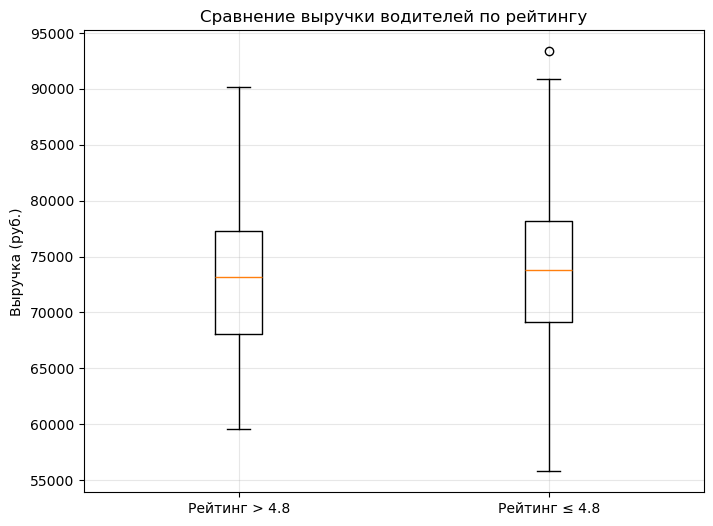

In [8]:
import matplotlib.pyplot as plt

# Данные для гипотезы 1: выручка водителей по рейтингу
df1 = pd.read_sql("""
    SELECT 
        d.driver_rating,
        SUM(r.ride_price) as revenue
    FROM rides r
    JOIN orders o ON r.order_id = o.order_id
    JOIN drivers d ON o.driver_id = d.driver_id
    WHERE DATE_PART('year', r.ride_started_at) = 2025
    GROUP BY d.driver_id, d.driver_rating
""", engine)

high = df1[df1['driver_rating'] > 4.8]['revenue']
low = df1[df1['driver_rating'] <= 4.8]['revenue']

t_stat, p = stats.ttest_ind(high, low)

print(f"Средняя выручка (рейтинг >4.8): {high.mean():.0f}")
print(f"Средняя выручка (рейтинг ≤4.8): {low.mean():.0f}")
print(f"p-value: {p:.4f}")

if p < 0.05:
    print("Вывод: Разница значима. Гипотеза подтвердилась.")
else:
    print("Вывод: Разница не значима. Гипотеза не подтвердилась.")

# ГРАФИК
plt.figure(figsize=(8, 6))
plt.boxplot([high, low], labels=['Рейтинг > 4.8', 'Рейтинг ≤ 4.8'])
plt.ylabel('Выручка (руб.)')
plt.title('Сравнение выручки водителей по рейтингу')
plt.grid(True, alpha=0.3)
plt.show()

# Гипотеза 2: в выходные средний чек выше

Средний чек в выходные: 401.23
Средний чек в будни: 402.04
p-value: 0.5260
Вывод: Разница не значима. Гипотеза не подтвердилась.


C:\Users\User\AppData\Local\Temp\ipykernel_4404\2489175812.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([weekend, weekday], labels=['Выходные', 'Будни'])


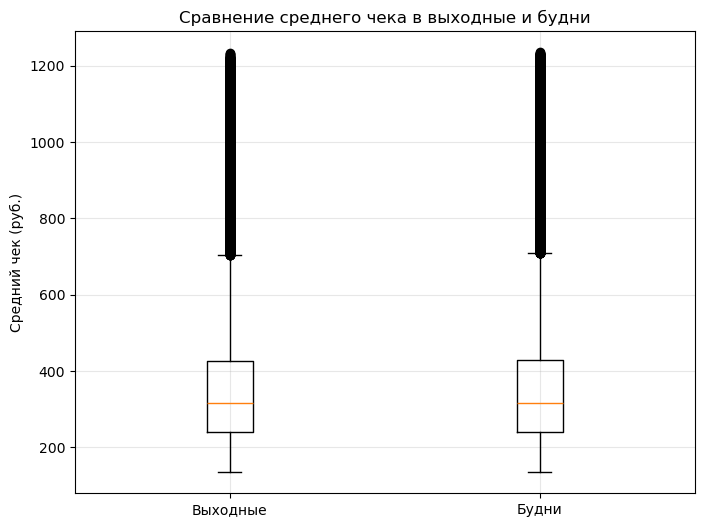

In [9]:
import matplotlib.pyplot as plt

# Данные для гипотезы 2: средний чек по выходным
df2 = pd.read_sql("""
    SELECT 
        ride_price,
        EXTRACT(DOW FROM ride_started_at) as weekday
    FROM rides
    WHERE DATE_PART('year', ride_started_at) = 2025
""", engine)

df2['is_weekend'] = df2['weekday'].isin([5, 6])
weekend = df2[df2['is_weekend']]['ride_price']
weekday = df2[~df2['is_weekend']]['ride_price']

t_stat, p = stats.ttest_ind(weekend, weekday)

print(f"Средний чек в выходные: {weekend.mean():.2f}")
print(f"Средний чек в будни: {weekday.mean():.2f}")
print(f"p-value: {p:.4f}")

if p < 0.05:
    print("Вывод: Разница значима. Гипотеза подтвердилась.")
else:
    print("Вывод: Разница не значима. Гипотеза не подтвердилась.")

# ГРАФИК
plt.figure(figsize=(8, 6))
plt.boxplot([weekend, weekday], labels=['Выходные', 'Будни'])
plt.ylabel('Средний чек (руб.)')
plt.title('Сравнение среднего чека в выходные и будни')
plt.grid(True, alpha=0.3)
plt.show()

# Гипотеза 3: конверсия city выше, чем intercity


Конверсия city: 89.95%
Конверсия intercity: 90.01%
p-value: 0.7454
Вывод: Разница не значима. Гипотеза не подтвердилась.


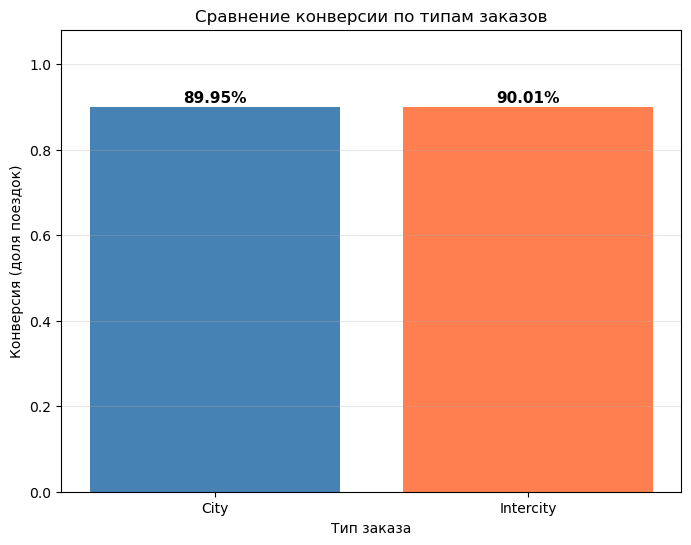

In [10]:
import matplotlib.pyplot as plt

# Данные для гипотезы 3: конверсия по типам
df3 = pd.read_sql("""
    SELECT 
        o.order_type,
        COUNT(DISTINCT o.order_id) as orders,
        COUNT(DISTINCT r.order_id) as rides
    FROM orders o
    LEFT JOIN rides r ON o.order_id = r.order_id
    WHERE DATE_PART('year', o.created_at) = 2025
    GROUP BY o.order_type
""", engine)

city = df3[df3['order_type'] == 'city']
inter = df3[df3['order_type'] == 'intercity']

city_conv = city['rides'].values[0] / city['orders'].values[0]
inter_conv = inter['rides'].values[0] / inter['orders'].values[0]

from statsmodels.stats.proportion import proportions_ztest
count = [city['rides'].values[0], inter['rides'].values[0]]
nobs = [city['orders'].values[0], inter['orders'].values[0]]
z_stat, p = proportions_ztest(count, nobs)

print(f"Конверсия city: {city_conv:.2%}")
print(f"Конверсия intercity: {inter_conv:.2%}")
print(f"p-value: {p:.4f}")

if p < 0.05:
    print("Вывод: Разница значима. Гипотеза подтвердилась.")
else:
    print("Вывод: Разница не значима. Гипотеза не подтвердилась.")

# ГРАФИК
plt.figure(figsize=(8, 6))
plt.bar(['City', 'Intercity'], [city_conv, inter_conv], 
        color=['steelblue', 'coral'])
plt.ylabel('Конверсия (доля поездок)')
plt.xlabel('Тип заказа')
plt.title('Сравнение конверсии по типам заказов')
plt.ylim(0, max(city_conv, inter_conv) * 1.2)

# Добавляем значения на столбцы
plt.text(0, city_conv + 0.01, f'{city_conv:.2%}', 
         ha='center', fontsize=11, fontweight='bold')
plt.text(1, inter_conv + 0.01, f'{inter_conv:.2%}', 
         ha='center', fontsize=11, fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.show()

# Гипотеза 4: Опытные водители (стаж >2 лет) зарабатывают больше новичков

ГИПОТЕЗА 4: Опытные водители (>2 лет) зарабатывают больше новичков (≤1 года)
Средняя выручка опытных: 73926
Средняя выручка новичков: 73424
p-value: 0.3297
❌ Не подтвердилась
--------------------------------------------------


C:\Users\User\AppData\Local\Temp\ipykernel_4404\2901377323.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([experienced, new], labels=['Опытные (>2 лет)', 'Новички (≤1 года)'])


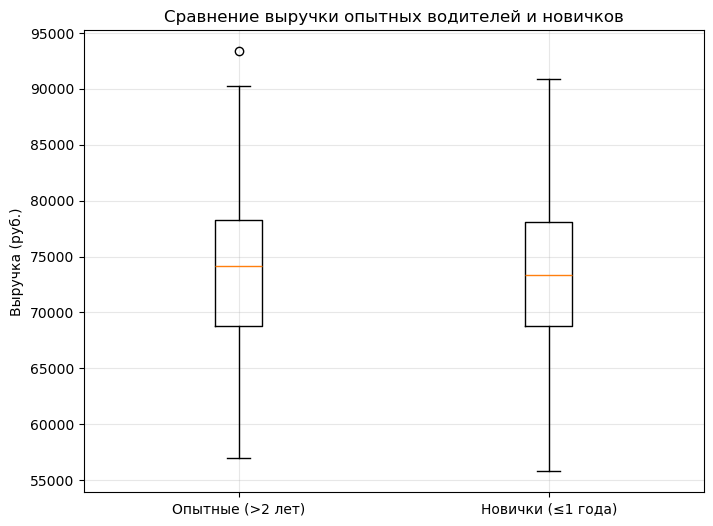

In [11]:
import matplotlib.pyplot as plt

df4 = pd.read_sql("""
    SELECT 
        d.experience_days,
        SUM(r.ride_price) as revenue
    FROM rides r
    JOIN orders o ON r.order_id = o.order_id
    JOIN drivers d ON o.driver_id = d.driver_id
    WHERE DATE_PART('year', r.ride_started_at) = 2025
    GROUP BY d.driver_id, d.experience_days
""", engine)

experienced = df4[df4['experience_days'] > 730]['revenue']  # >2 года
new = df4[df4['experience_days'] <= 365]['revenue']         # <=1 год

t_stat, p = stats.ttest_ind(experienced, new)

print("ГИПОТЕЗА 4: Опытные водители (>2 лет) зарабатывают больше новичков (≤1 года)")
print(f"Средняя выручка опытных: {experienced.mean():.0f}")
print(f"Средняя выручка новичков: {new.mean():.0f}")
print(f"p-value: {p:.4f}")
print("✅ Подтвердилась" if p < 0.05 else "❌ Не подтвердилась")
print("-"*50)

# ГРАФИК
plt.figure(figsize=(8, 6))
plt.boxplot([experienced, new], labels=['Опытные (>2 лет)', 'Новички (≤1 года)'])
plt.ylabel('Выручка (руб.)')
plt.title('Сравнение выручки опытных водителей и новичков')
plt.grid(True, alpha=0.3)
plt.show()

# Гипотеза 5: Вечером (18-23) средний чек выше, чем утром (6-11)

ГИПОТЕЗА 5: Вечером (18-23) средний чек выше, чем утром (6-11)
Средний чек вечером: 400.86
Средний чек утром: 402.56
p-value: 0.2315
❌ Не подтвердилась
--------------------------------------------------


C:\Users\User\AppData\Local\Temp\ipykernel_4404\3529401186.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([evening, morning], labels=['Вечер (18-23)', 'Утро (6-11)'])


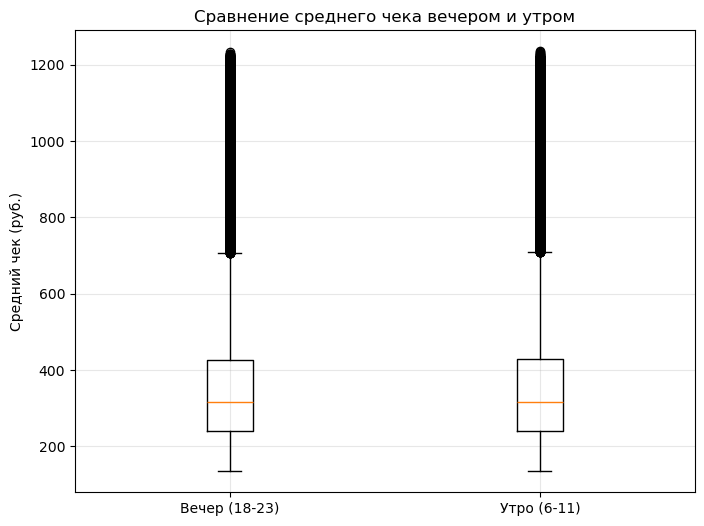

In [12]:
import matplotlib.pyplot as plt

df5 = pd.read_sql("""
    SELECT 
        ride_price,
        EXTRACT(HOUR FROM ride_started_at) as hour
    FROM rides
    WHERE DATE_PART('year', ride_started_at) = 2025
""", engine)

evening = df5[df5['hour'].between(18, 23)]['ride_price']
morning = df5[df5['hour'].between(6, 11)]['ride_price']

t_stat, p = stats.ttest_ind(evening, morning)

print("ГИПОТЕЗА 5: Вечером (18-23) средний чек выше, чем утром (6-11)")
print(f"Средний чек вечером: {evening.mean():.2f}")
print(f"Средний чек утром: {morning.mean():.2f}")
print(f"p-value: {p:.4f}")
print("✅ Подтвердилась" if p < 0.05 else "❌ Не подтвердилась")
print("-"*50)

# ГРАФИК
plt.figure(figsize=(8, 6))
plt.boxplot([evening, morning], labels=['Вечер (18-23)', 'Утро (6-11)'])
plt.ylabel('Средний чек (руб.)')
plt.title('Сравнение среднего чека вечером и утром')
plt.grid(True, alpha=0.3)
plt.show()